In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, KFold
from sklearn.metrics import make_scorer, mean_squared_error, mean_absolute_error, r2_score
from sklearn.linear_model import LinearRegression, Lasso
from xgboost import XGBRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import time
import os
from skopt import BayesSearchCV
from skopt.space import Real, Integer, Categorical
import joblib
from sklearn.preprocessing import MinMaxScaler

import warnings
warnings.filterwarnings('ignore')

In [ ]:
# Dataset configurations (you just need to keep adding your dataset to this directory and add the target variable name + the dataset name)
DATASETS = {
    "calingiri": {
        "file": "3_merged_data3.txt",
        "target": "avg7_calingiri",
        "display_name": "Calingiri"
    },
    "lancer": {
        "file": "3_merged_data1.txt", 
        "target": "avg7_lancer",
        "display_name": "Lancer"
    },
    "halberd": {
        "file": "3_merged_data5.txt",
        "target": "avg_halberd",
        "display_name": "Halberd"
    }
}


In [3]:

# Define models (preserved from original)
def get_models():
    return {
        "Linear Regression": LinearRegression(n_jobs=4),
        "Decision Tree": DecisionTreeRegressor(),
        #"Random Forest": RandomForestRegressor(n_jobs=1),
        "Gradient Boosting": GradientBoostingRegressor(),
        "Lasso Regression": Lasso(),
    }


In [4]:

# Define scoring metrics (preserved from original)
def get_scoring():
    return {
        'MSE': make_scorer(mean_squared_error, greater_is_better=False),
        'MAE': make_scorer(mean_absolute_error, greater_is_better=False),
        'R2': make_scorer(r2_score)
    }


In [5]:

# Create Bayesian SearchCV setup (preserved from original)
def create_bayesian_searches(X, y, param_spaces, k_values):
    searches = {}
    models = get_models()

    for model_name, model in models.items():
        search_spaces = param_spaces.get(model_name, {})
        if not search_spaces:
            print(f"Skipping {model_name} because search space is empty.")
            continue

        for k in k_values:
            cv = KFold(n_splits=k, shuffle=True, random_state=42)
            search = BayesSearchCV(
                estimator=model,
                search_spaces=search_spaces,
                scoring='r2',
                cv=cv,
                n_iter=32,
                n_jobs=-1,
                verbose=2,
                random_state=42
            )
            key = f"{model_name} (K={k})"
            searches[key] = search

    return searches


In [6]:

# Parameter spaces (preserved from original)
def get_param_spaces():
    return {
        "Linear Regression": {},  # no params to tune
        "Decision Tree": {
            "max_depth": Integer(3, 20)  # continuous range from 3 to 20
        },
        #"Random Forest": {
         #   "n_estimators": Integer(50, 200),
          #  "max_depth": Integer(5, 20)
        #},
        "Gradient Boosting": {
           "n_estimators": Integer(50, 200),
           "learning_rate": Real(0.01, 0.1, prior='log-uniform')
        },
        "Lasso Regression": {
            "alpha": Real(0.01, 10.0, prior='log-uniform')
        }
    }


In [7]:

# Training function with progress (preserved from original with dataset naming)
def train_with_progress_bayesian(searches, X, y, dataset_name="", save_dir="saved_models_bayes_task4"):
    all_results = []

    # Add dataset name to save directory
    if dataset_name:
        save_dir = f"{save_dir}_{dataset_name.lower()}"
    
    os.makedirs(save_dir, exist_ok=True)
    total_tasks = len(searches)
    pbar = tqdm(total=total_tasks, desc=f"Bayesian Training {dataset_name}", ncols=100)

    for idx, (name, search) in enumerate(searches.items(), 1):
        print(f"\n🔍 Starting training for: {name} - {dataset_name}")
        start_time = time.time()

        # Fit model quietly
        search.fit(X, y)

        best_model = search.best_estimator_
        best_params = search.best_params_

        y_pred = best_model.predict(X)

        mean_mse = mean_squared_error(y, y_pred)
        mean_mae = mean_absolute_error(y, y_pred)
        mean_r2  = r2_score(y, y_pred)

        safe_name = name.replace(" ", "_").replace("(", "").replace(")", "").replace("=", "")
        # Add dataset name to model filename
        if dataset_name:
            model_filename = f"{dataset_name}_{safe_name}.pkl"
        else:
            model_filename = f"{safe_name}.pkl"
        
        model_path = os.path.join(save_dir, model_filename)
        joblib.dump(best_model, model_path)

        elapsed = round(time.time() - start_time, 2)
        print(f"✅ Finished {name} | Time: {elapsed}s | R2: {mean_r2:.4f} | MSE: {mean_mse:.4f}")

        all_results.append({
            "Dataset": dataset_name,
            "Model": name,
            "Best Params": best_params,
            "MSE": mean_mse,
            "MAE": mean_mae,
            "R2": mean_r2,
            "Training Time (s)": elapsed
        })

        pbar.update(1)

        # Optional: print every 2 or 3 models milestone
        if idx % 3 == 0 or idx == total_tasks:
            print(f"🚀 Progress milestone: {idx}/{total_tasks} models trained.")

    pbar.close()

    results_df = pd.DataFrame(all_results)
    results_df = results_df.sort_values(by="R2", ascending=False)
    return results_df


In [8]:

# Model filename parser (preserved from original with dataset support)
def parse_model_filename(model_name: str, dataset_name: str = "") -> str:
    """
    Converts 'Random Forest (K=5)' → 'Random_Forest_K5.pkl'
    """
    import re
    name_clean = model_name.split(" (")[0].replace(" ", "_")
    k_match = re.search(r"K=(\d+)", model_name)
    k_value = f"K{k_match.group(1)}" if k_match else ""
    
    if dataset_name:
        return f"{dataset_name}_{name_clean}_{k_value}.pkl"
    else:
        return f"{name_clean}_{k_value}.pkl"


In [9]:
# Best model evaluation (preserved from original with dataset support)
def evaluate_and_predict_best_model(results_df, X_test, y_test, dataset_name="", save_dir="saved_models_bayes_task4"):
    df = results_df.copy()
    
    # Add dataset name to save directory
    if dataset_name:
        save_dir = f"{save_dir}_{dataset_name.lower()}"

    # Normalize metrics for combined score
    df["Inv_MSE"] = -df["MSE"]
    df["Inv_MAE"] = -df["MAE"]
    scaler = MinMaxScaler()
    df[["Norm_R2", "Norm_MSE", "Norm_MAE"]] = scaler.fit_transform(df[["R2", "Inv_MSE", "Inv_MAE"]])
    df["Combined_Score"] = df["Norm_R2"] + df["Norm_MSE"] + df["Norm_MAE"]

    # Pick best model
    best_model_info = df.sort_values("Combined_Score", ascending=False).iloc[0]
    model_name = best_model_info["Model"]
    model_file = parse_model_filename(model_name, dataset_name)
    model_path = os.path.join(save_dir, model_file)

    print(f"🏆 Best Model Info for {dataset_name}:")
    print(best_model_info[["Model", "R2", "MSE", "MAE", "Combined_Score"]])
    print(f"\n📦 Loading model from: {model_path}")

    # Load and predict
    best_model = joblib.load(model_path)
    y_pred = best_model.predict(X_test)

    # Evaluate
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)

    print(f"\n📊 Evaluation on Test Set for {dataset_name}:")
    print(f"R² Score: {r2:.4f}")
    print(f"MAE: {mae:.4f}")
    print(f"MSE: {mse:.4f}")

    # Compare predictions
    df_compare = pd.DataFrame({"Actual": y_test[:10], "Predicted": y_pred[:10]})
    print(f"\n🔍 Actual vs Predicted (First 10 Samples) for {dataset_name}:")
    print(df_compare)

    return best_model_info, y_pred


In [10]:

# Visualization functions (preserved from original with dataset support)
def plot_model_performance(results_df, dataset_name=""):
    metrics = ['R2', 'MAE', 'MSE']
    titles = {'R2': 'R² Score', 'MAE': 'Mean Absolute Error', 'MSE': 'Mean Squared Error'}

    plt.figure(figsize=(18, 6))  # Wider figure for 3 subplots

    for i, metric in enumerate(metrics, 1):
        plt.subplot(1, 3, i)
        sns.barplot(data=results_df, x='Model', y=metric, palette='viridis')
        plt.title(f"{titles[metric]} - {dataset_name}")
        plt.xticks(rotation=45)
        plt.grid(True)
        plt.tight_layout()

    plt.suptitle(f"Model Performance Comparison - {dataset_name}", fontsize=16, y=1.05)
    plt.show()


In [11]:

def plot_actual_vs_predicted(y_true, y_pred, model_name="Model", dataset_name=""):
    plt.figure(figsize=(6, 6))
    plt.scatter(y_true, y_pred, alpha=0.6, edgecolors='k')
    plt.plot([min(y_true), max(y_true)], [min(y_true), max(y_true)], 'r--')
    plt.xlabel("Actual Values")
    plt.ylabel("Predicted Values")
    plt.title(f"Actual vs Predicted: {model_name} - {dataset_name}")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [12]:

def plot_time_vs_r2(results_df, dataset_name=""):
    plt.figure(figsize=(8, 6))
    sns.scatterplot(
        data=results_df,
        x='Training Time (s)',
        y='R2',
        size='R2',
        hue='Model',
        sizes=(50, 300),
        palette='coolwarm',
        legend=False
    )
    plt.title(f"Training Time vs R² Score - {dataset_name}")
    plt.xlabel("Training Time (seconds)")
    plt.ylabel("R² Score")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [13]:

def plot_error_distribution(y_true, y_pred, model_name="Model", dataset_name=""):
    errors = y_true - y_pred
    plt.figure(figsize=(8, 5))
    sns.histplot(errors, bins=30, kde=True, color='purple')
    plt.title(f"Prediction Error Distribution: {model_name} - {dataset_name}")
    plt.xlabel("Error")
    plt.ylabel("Frequency")
    plt.grid(True)
    plt.tight_layout()
    plt.show()


In [14]:

# New function for cross-dataset summary
def create_summary_comparison(all_results):
    """Create a summary comparison across all datasets"""
    summary_data = []
    
    for dataset_name, results_df in all_results.items():
        best_model = results_df.iloc[0]
        summary_data.append({
            'Dataset': dataset_name,
            'Best_Model': best_model['Model'],
            'R2': best_model['R2'],
            'MSE': best_model['MSE'],
            'MAE': best_model['MAE'],
            'Training_Time_s': best_model['Training Time (s)']
        })
    
    summary_df = pd.DataFrame(summary_data)
    
    # Plot summary comparison
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # R² comparison
    sns.barplot(data=summary_df, x='Dataset', y='R2', ax=axes[0,0], palette='viridis')
    axes[0,0].set_title('Best R² Score by Dataset')
    axes[0,0].set_ylabel('R² Score')
    
    # MSE comparison
    sns.barplot(data=summary_df, x='Dataset', y='MSE', ax=axes[0,1], palette='plasma')
    axes[0,1].set_title('Best MSE by Dataset')
    axes[0,1].set_ylabel('MSE')
    
    # MAE comparison
    sns.barplot(data=summary_df, x='Dataset', y='MAE', ax=axes[1,0], palette='cividis')
    axes[1,0].set_title('Best MAE by Dataset')
    axes[1,0].set_ylabel('MAE')
    
    # Training time comparison
    sns.barplot(data=summary_df, x='Dataset', y='Training_Time_s', ax=axes[1,1], palette='magma')
    axes[1,1].set_title('Training Time by Dataset')
    axes[1,1].set_ylabel('Training Time (s)')
    
    plt.suptitle('Performance Summary Across All Datasets', fontsize=16)
    plt.tight_layout()
    plt.show()
    
    return summary_df


In [15]:

# Main execution function
def main():
    """
    Main execution function that processes all datasets
    """
    print("🔬 Multi-Dataset Bayesian Optimization Pipeline")
    print("="*60)
    
    # Configuration (preserved from original)
    k_values = [3,5,7]
    param_spaces = get_param_spaces()
    
    # Storage for all results
    all_results = {}
    all_best_models = {}
    
    # Process each dataset
    for dataset_key, dataset_config in DATASETS.items():
        print(f"\n{'='*60}")
        print(f"Processing Dataset: {dataset_config['display_name']}")
        print(f"File: {dataset_config['file']}")
        print(f"Target: {dataset_config['target']}")
        print(f"{'='*60}")
        
        try:
            # Data loading and splitting (similar to original)
            df = pd.read_csv(dataset_config['file'], sep='\t')
            print(f"Dataset shape: {df.shape}")
            
            # Separate features and target
            X = df.drop(columns=['ID', dataset_config['target']])
            y = df[dataset_config['target']]

            X_train, X_test, y_train, y_test = train_test_split(
                X, y, test_size=0.2, random_state=42
            )

            print(f"X_train shape: {X_train.shape}")
            print(f"X_test shape: {X_test.shape}")

            # Create grid searches (preserved from original)
            searches = create_bayesian_searches(X_train, y_train, param_spaces, k_values)

            # Run training (preserved from original with dataset name)
            results_df = train_with_progress_bayesian(searches, X_train, y_train, dataset_config['display_name'])
            
            # Save results with dataset name
            results_df.to_csv(f"{dataset_key}_model_results.csv", index=False)
            all_results[dataset_config['display_name']] = results_df

            # Load best model and predict (preserved from original)
            best_model, y_pred = evaluate_and_predict_best_model(results_df, X_test, y_test, dataset_config['display_name'])
            all_best_models[dataset_config['display_name']] = {
                'best_model': best_model,
                'y_test': y_test,
                'y_pred': y_pred
            }

            print(f"\n📈 Creating visualizations for {dataset_config['display_name']}...")

            # Visualizations (preserved from original with dataset names)
            # 1. Bar charts for R2, MAE, MSE
            plot_model_performance(results_df, dataset_config['display_name'])

            # 2. Plot actual vs predicted
            plot_actual_vs_predicted(y_test, y_pred, best_model["Model"], dataset_config['display_name'])

            # 3. Training time vs performance
            plot_time_vs_r2(results_df, dataset_config['display_name'])

            # 4. Error distribution
            plot_error_distribution(y_test, y_pred, best_model["Model"], dataset_config['display_name'])
            
            print(f"✅ Completed processing for {dataset_config['display_name']}")
            
        except Exception as e:
            print(f"❌ Error processing {dataset_key}: {str(e)}")
            continue
    
    # Create summary comparison across all datasets
    if all_results:
        print(f"\n{'='*60}")
        print("Creating Summary Comparison Across All Datasets")
        print(f"{'='*60}")
        
        summary_df = create_summary_comparison(all_results)
        summary_df.to_csv("dataset_summary_comparison.csv", index=False)
        
        print("\n📊 Final Summary:")
        print(summary_df.to_string(index=False))
    
    print(f"\n{'='*60}")
    print("🎉 Multi-Dataset Analysis Complete!")
    print(f"{'='*60}")


🔬 Multi-Dataset Bayesian Optimization Pipeline

Processing Dataset: Calingiri
File: 3_merged_data3.txt
Target: avg7_calingiri
Dataset shape: (149, 33050)
X_train shape: (119, 33048)
X_test shape: (30, 33048)
Skipping Linear Regression because search space is empty.


Bayesian Training Calingiri:   0%|                                            | 0/9 [00:00<?, ?it/s]


🔍 Starting training for: Decision Tree (K=3) - Calingiri
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fit

Bayesian Training Calingiri:  11%|████                                | 1/9 [00:27<03:40, 27.57s/it]

✅ Finished Decision Tree (K=3) | Time: 27.57s | R2: 0.4771 | MSE: 0.8420

🔍 Starting training for: Decision Tree (K=5) - Calingiri
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, t

...

✅ Finished Lasso Regression (K=3) | Time: 15.12s | R2: 0.0000 | MSE: 1.6102

🔍 Starting training for: Lasso Regression (K=5) - Calingiri
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candida

Bayesian Training Calingiri:  89%|███████████████████████████████    | 8/9 [20:27<02:22, 142.55s/it]

✅ Finished Lasso Regression (K=5) | Time: 17.0s | R2: 0.0000 | MSE: 1.6102

🔍 Starting training for: Lasso Regression (K=7) - Calingiri
Fitting 7 folds for each of 1 candidates, totalling 7 fits
Fitting 7 folds for each of 1 candidates, totalling 7 fits
Fitting 7 folds for each of 1 candidates, totalling 7 fits
Fitting 7 folds for each of 1 candidates, totalling 7 fits
Fitting 7 folds for each of 1 candidates, totalling 7 fits
Fitting 7 folds for each of 1 candidates, totalling 7 fits
Fitting 7 folds for each of 1 candidates, totalling 7 fits
Fitting 7 folds for each of 1 candidates, totalling 7 fits
Fitting 7 folds for each of 1 candidates, totalling 7 fits
Fitting 7 folds for each of 1 candidates, totalling 7 fits
Fitting 7 folds for each of 1 candidates, totalling 7 fits
Fitting 7 folds for each of 1 candidates, totalling 7 fits
Fitting 7 folds for each of 1 candidates, totalling 7 fits
Fitting 7 folds for each of 1 candidates, totalling 7 fits
Fitting 7 folds for each of 1 candidat

Bayesian Training Calingiri: 100%|███████████████████████████████████| 9/9 [20:50<00:00, 138.98s/it]

✅ Finished Lasso Regression (K=7) | Time: 23.09s | R2: 0.2195 | MSE: 1.2567
🚀 Progress milestone: 9/9 models trained.
🏆 Best Model Info for Calingiri:
Model             Gradient Boosting (K=3)
R2                               0.567297
MSE                              0.696734
MAE                              0.676952
Combined_Score                        3.0
Name: 3, dtype: object

📦 Loading model from: saved_models_bayes_task4_calingiri\Calingiri_Gradient_Boosting_K3.pkl

📊 Evaluation on Test Set for Calingiri:
R² Score: -0.0337
MAE: 0.9924
MSE: 1.4242

🔍 Actual vs Predicted (First 10 Samples) for Calingiri:
     Actual  Predicted
73     4.67   4.514071
18     5.00   3.905056
117    2.33   3.893817
78     3.33   3.828623
76     5.00   3.706733
31     6.00   4.004734
64     4.33   3.939254
140    3.33   4.347244
68     5.33   4.384577
82     6.83   4.168481

📈 Creating visualizations for Calingiri...


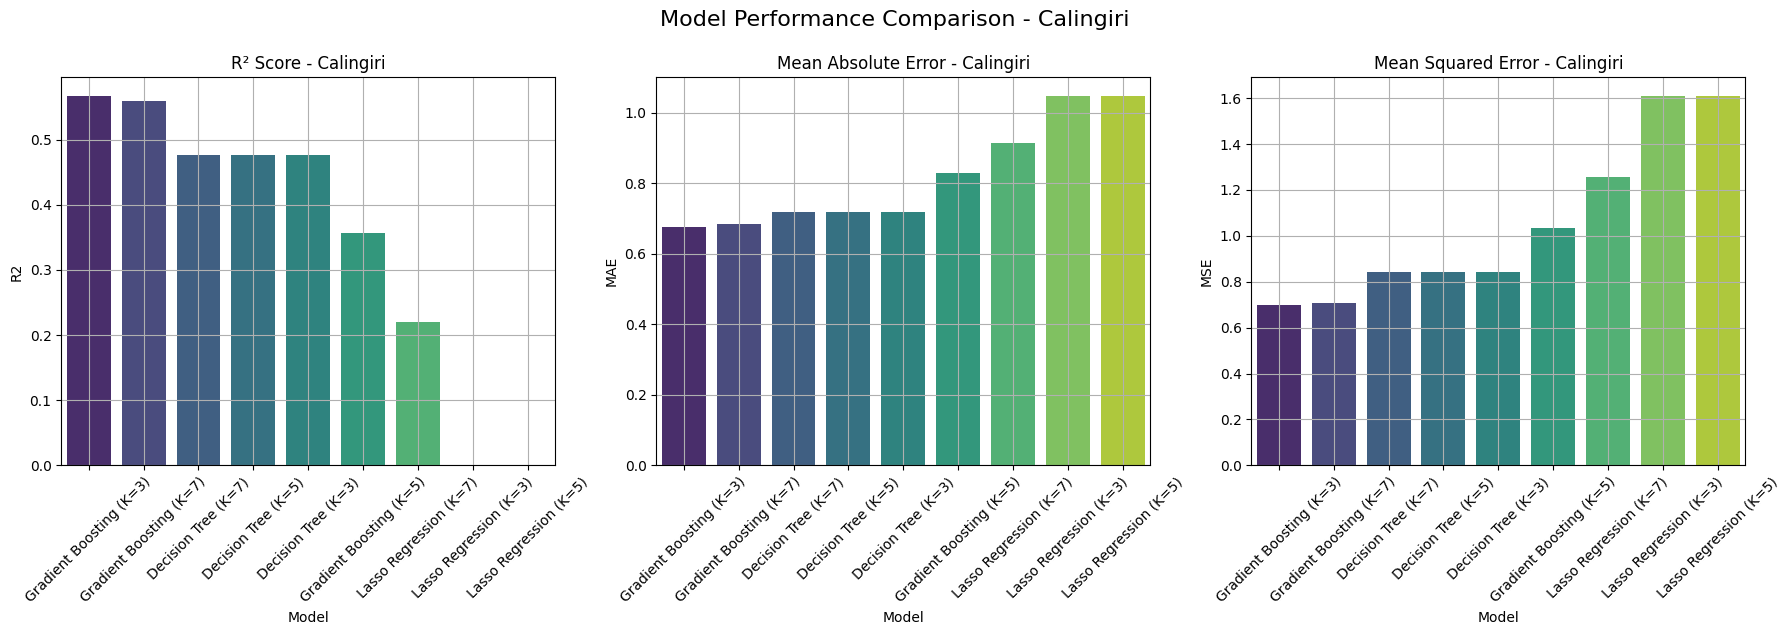

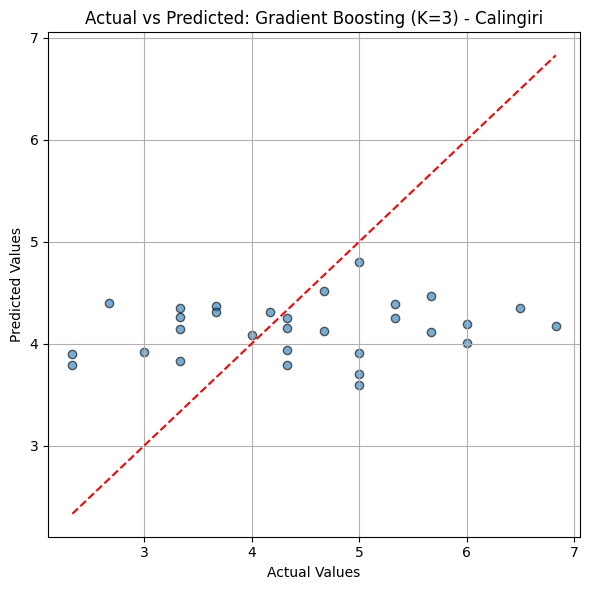

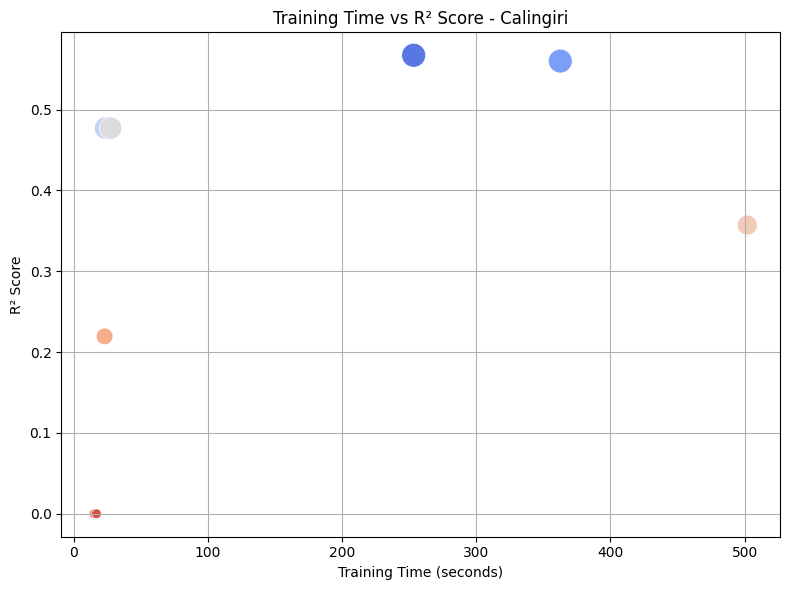

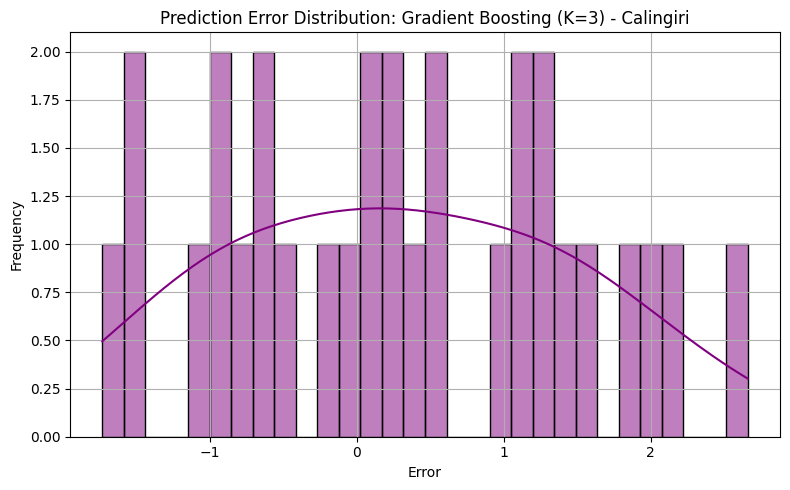

✅ Completed processing for Calingiri

Processing Dataset: Lancer
File: 3_merged_data1.txt
Target: avg7_lancer
Dataset shape: (149, 33050)
X_train shape: (119, 33048)
X_test shape: (30, 33048)
Skipping Linear Regression because search space is empty.


Bayesian Training Lancer:   0%|                                               | 0/9 [00:00<?, ?it/s]


🔍 Starting training for: Decision Tree (K=3) - Lancer
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
F

Bayesian Training Lancer:  11%|████▎                                  | 1/9 [00:21<02:50, 21.29s/it]

✅ Finished Decision Tree (K=3) | Time: 21.29s | R2: 0.4336 | MSE: 0.9590

🔍 Starting training for: Decision Tree (K=5) - Lancer
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, tota

...

✅ Finished Decision Tree (K=7) | Time: 27.43s | R2: 0.6341 | MSE: 0.6195
🚀 Progress milestone: 3/9 models trained.

🔍 Starting training for: Gradient Boosting (K=3) - Lancer
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits
Fitting 3 folds for each of 1 candidates, totalling 3 fits


Bayesian Training Lancer:  44%|████████████████▉                     | 4/9 [06:35<11:52, 142.49s/it]

✅ Finished Gradient Boosting (K=3) | Time: 322.99s | R2: 0.3434 | MSE: 1.1117

🔍 Starting training for: Gradient Boosting (K=5) - Lancer
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candidates, totalling 5 fits
Fitting 5 folds for each of 1 candida

Bayesian Training Lancer:  56%|█████████████████████                 | 5/9 [12:41<14:52, 223.16s/it]

✅ Finished Gradient Boosting (K=5) | Time: 366.18s | R2: 0.3383 | MSE: 1.1203

🔍 Starting training for: Gradient Boosting (K=7) - Lancer
Fitting 7 folds for each of 1 candidates, totalling 7 fits
Fitting 7 folds for each of 1 candidates, totalling 7 fits
Fitting 7 folds for each of 1 candidates, totalling 7 fits
Fitting 7 folds for each of 1 candidates, totalling 7 fits
Fitting 7 folds for each of 1 candidates, totalling 7 fits
Fitting 7 folds for each of 1 candidates, totalling 7 fits
Fitting 7 folds for each of 1 candidates, totalling 7 fits
Fitting 7 folds for each of 1 candidates, totalling 7 fits
Fitting 7 folds for each of 1 candidates, totalling 7 fits
Fitting 7 folds for each of 1 candidates, totalling 7 fits
Fitting 7 folds for each of 1 candidates, totalling 7 fits
Fitting 7 folds for each of 1 candidates, totalling 7 fits
Fitting 7 folds for each of 1 candidates, totalling 7 fits
Fitting 7 folds for each of 1 candidates, totalling 7 fits
Fitting 7 folds for each of 1 candida

In [ ]:
# Execute if run directly
if __name__ == "__main__":
    main()